In [3]:
import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sqlalchemy import create_engine


from src.config import settings

In [4]:
engine = create_engine(settings.database_url)

raw = pd.read_sql("""
    SELECT ticker, date, open, high, low, close, volume, adjusted_close, source
    FROM daily_prices
    WHERE source = 'yfinance'
""", engine)

data_processed = pd.read_csv("../data/processed/v1/features_all_tickers.csv")

raw["date"] = pd.to_datetime(raw["date"])
data_processed["date"] = pd.to_datetime(data_processed["date"])

print("Raw tickers:", sorted(raw["ticker"].unique()))
print("Processed tickers:", sorted(data_processed["ticker"].unique()))

merged = data_processed.merge(
    raw,
    on=["ticker", "date"],
    how="left",
    suffixes=("_processed", "_raw"),
)

print("Processed rows with missing raw match:", merged["open_raw"].isna().sum())

Raw tickers: ['AAPL', 'AMZN', 'CAT', 'GOOGL', 'JNJ', 'JPM', 'MSFT', 'NVDA', 'SPY', 'WMT', 'XOM']
Processed tickers: ['AAPL', 'AMZN', 'CAT', 'GOOGL', 'JNJ', 'JPM', 'MSFT', 'NVDA', 'SPY', 'WMT', 'XOM']
Processed rows with missing raw match: 0


In [5]:
print(sorted(data_processed["ticker"].unique()))

['AAPL', 'AMZN', 'CAT', 'GOOGL', 'JNJ', 'JPM', 'MSFT', 'NVDA', 'SPY', 'WMT', 'XOM']


In [6]:
print(f"The number of unique tickers: {data_processed['ticker'].nunique()}.")
print(f"The data ranges from: {data_processed['date'].min()} to {data_processed['date'].max()}.")

The number of unique tickers: 11.
The data ranges from: 2021-08-19 00:00:00 to 2026-08-06 00:00:00.


In [7]:
print("\nMissing values:")
print(data_processed.isna().sum().sort_values(ascending=False))

print("\nDuplicate ticker-date rows:")
print(data_processed.duplicated(subset=["ticker", "date"]).sum())


Missing values:
ticker                     0
return_5d                  0
close_open_return          0
high_low_range_pct         0
volatility_ratio_5d_20d    0
volatility_20d             0
volatility_5d              0
return_20d                 0
return_10d                 0
return_1d                  0
date                       0
source                     0
adjusted_close             0
volume                     0
close                      0
low                        0
high                       0
open                       0
drawdown_20d               0
dtype: int64

Duplicate ticker-date rows:
0


In [8]:
print("\nRows per ticker:")

print(data_processed.groupby("ticker").size().sort_values())


Rows per ticker:
ticker
GOOGL    1234
JNJ      1234
JPM      1234
SPY      1234
AAPL     1245
AMZN     1246
CAT      1246
MSFT     1246
NVDA     1246
WMT      1246
XOM      1246
dtype: int64


In [21]:
data_processed.info()

<class 'pandas.DataFrame'>
RangeIndex: 13657 entries, 0 to 13656
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   ticker                   13657 non-null  str           
 1   date                     13657 non-null  datetime64[us]
 2   open                     13657 non-null  float64       
 3   high                     13657 non-null  float64       
 4   low                      13657 non-null  float64       
 5   close                    13657 non-null  float64       
 6   volume                   13657 non-null  int64         
 7   adjusted_close           13657 non-null  float64       
 8   source                   13657 non-null  str           
 9   return_1d                13657 non-null  float64       
 10  return_5d                13657 non-null  float64       
 11  return_10d               13657 non-null  float64       
 12  return_20d               13657 non-null  fl

In [22]:
data_processed.head(1)

,ticker,date,open,high,low,close,volume,adjusted_close,source,return_1d,return_5d,return_10d,return_20d,volatility_5d,volatility_20d,volatility_ratio_5d_20d,high_low_range_pct,close_open_return,drawdown_20d
0,AAPL,2021-08-19,145.029999,148.0,144.5,146.699997,86960300,143.210358,yfinance,0.002323,-0.014709,-0.002448,-0.000681,0.014472,0.010473,1.381921,0.023858,0.011515,-0.029248


### Normalized Adjusted Close Returns

As an example, a value of 2.0 would mean a 100% increase in the stock value, while 0.8 would mean a 20% decrease from the initial value recorded.


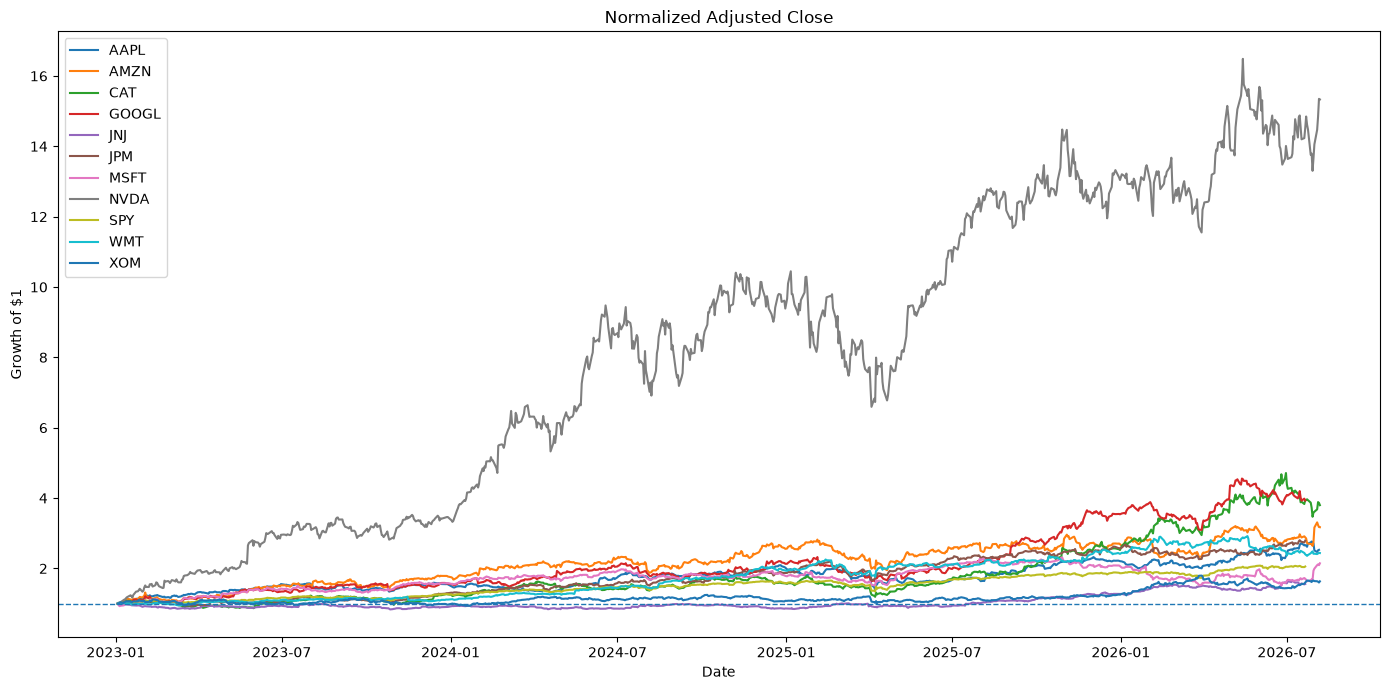

In [10]:
# Normalize returns
start_date = "2023-01-01"

sorted_data = (
    data_processed[data_processed['date'] >= start_date]
        .sort_values(["ticker", "date"])
        .copy()
)

sorted_data["normalized_close"] = (
    sorted_data.groupby("ticker")["adjusted_close"]
      .transform(lambda x: x / x.iloc[0]) # applies this function to every group, but return one value/row
)

plt.figure(figsize=(14, 7))

for ticker, group in sorted_data.groupby("ticker"):
    plt.plot(group["date"], group["normalized_close"], label=ticker)

plt.axhline(1, linestyle="--", linewidth=1)
plt.title("Normalized Adjusted Close")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.tight_layout()
plt.show()

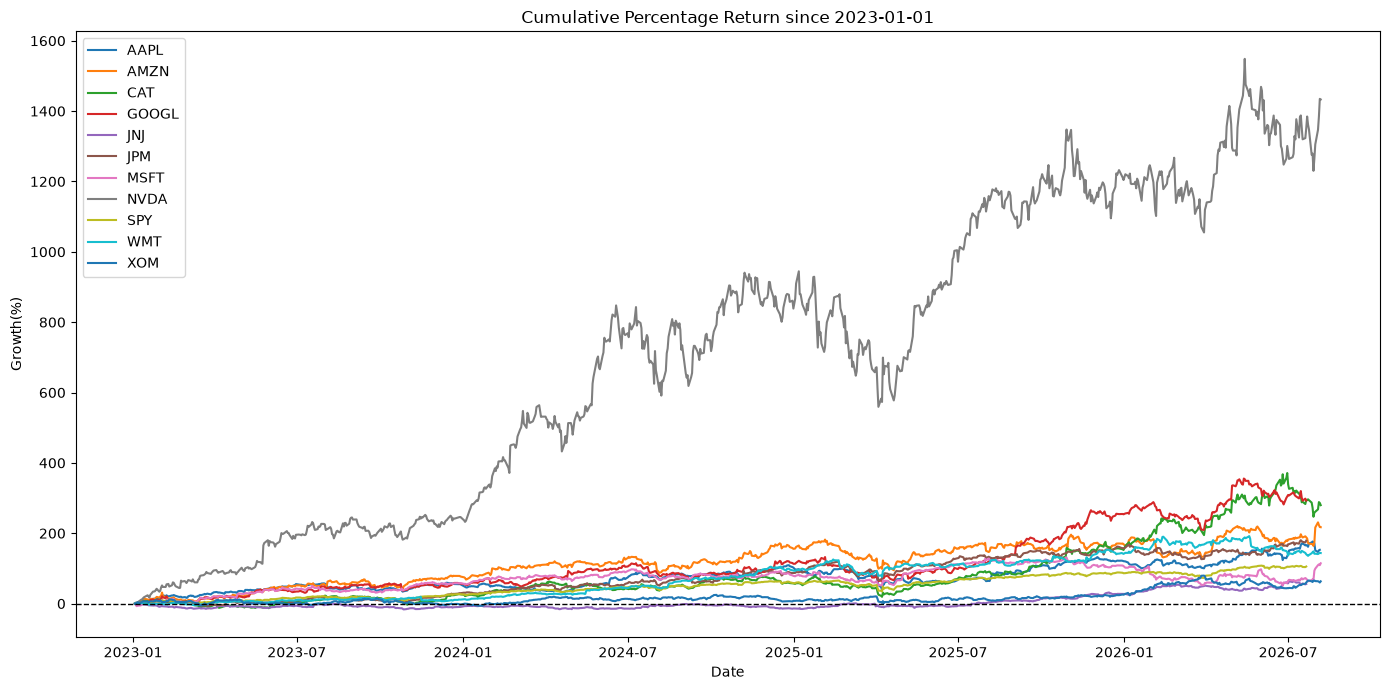

In [11]:
plt.figure(figsize=(14, 7))

for ticker, group in sorted_data.groupby("ticker"):
    plt.plot(group["date"], (group["normalized_close"] - 1) * 100, label=ticker)

plt.axhline(0, linestyle="--", linewidth=1, color = 'black')
plt.title(f"Cumulative Percentage Return since {start_date}")
plt.xlabel("Date")
plt.ylabel("Growth(%)")
plt.legend()
plt.tight_layout()
plt.show()

### Daily Returns Distribution

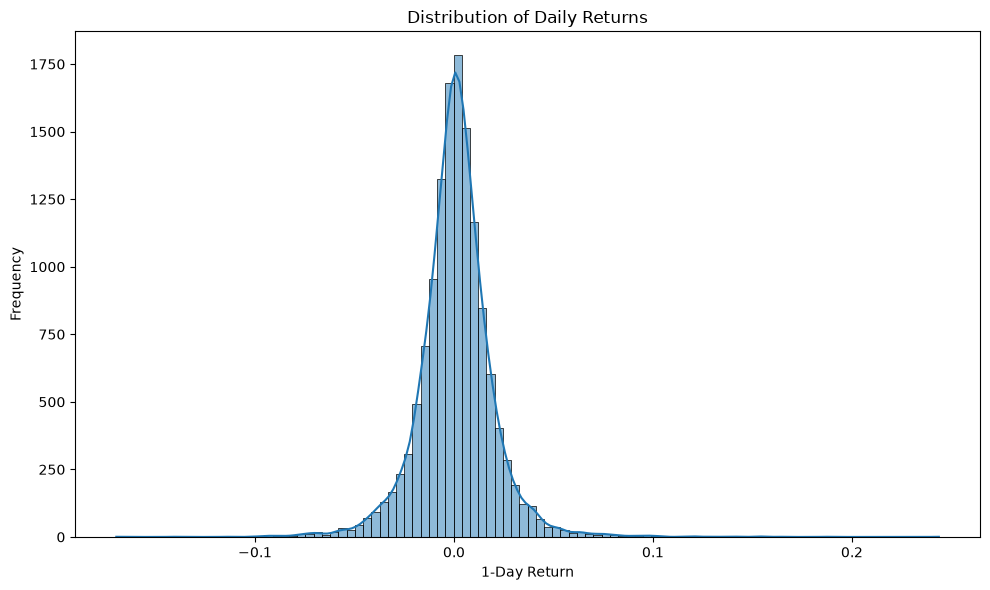

In [12]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=data_processed,
    x="return_1d",
    bins=100,
    kde=True
)

plt.title("Distribution of Daily Returns")
plt.xlabel("1-Day Return")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

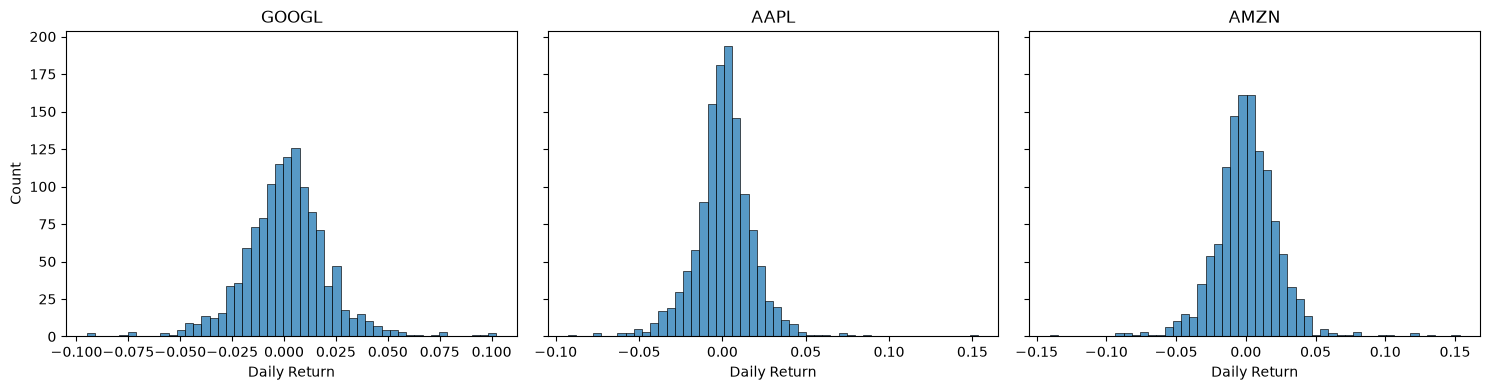

In [13]:
ticker_set = {"AAPL", "AMZN", "GOOGL"}

temp_data = data_processed[
    data_processed["ticker"].isin(ticker_set)
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, ticker in zip(axes, ticker_set):
    sns.histplot(
        data=temp_data[temp_data["ticker"] == ticker],
        x="return_1d",
        bins=50,
        ax=ax
    )
    ax.set_title(ticker)
    ax.set_xlabel('Daily Return')

plt.tight_layout()
plt.show()

### Volatility Analysis

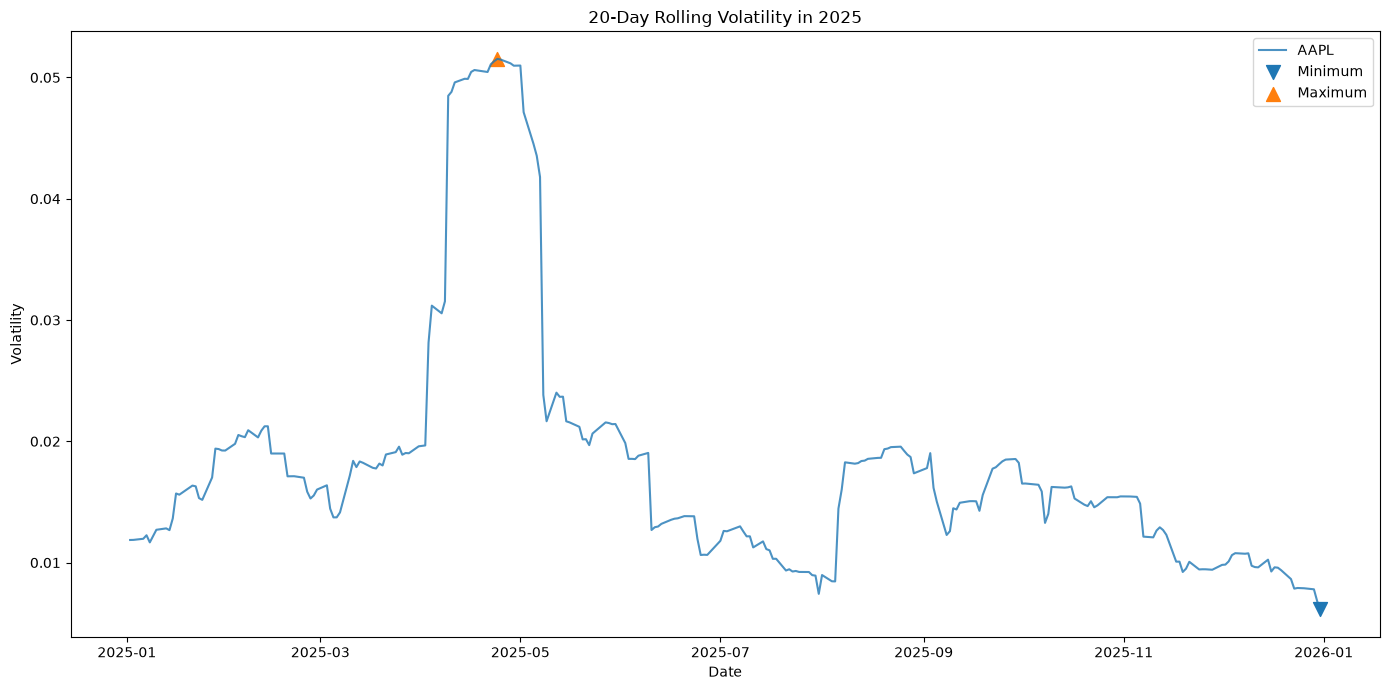

In [14]:
ticker = 'AAPL'
temp_data = data_processed[
    (data_processed['ticker'] == ticker) &
    (data_processed['date'].dt.year == 2025)
]

# find min and max values along the year
min_idx = temp_data["volatility_20d"].idxmin()
max_idx = temp_data["volatility_20d"].idxmax()

min_point = temp_data.loc[min_idx]
max_point = temp_data.loc[max_idx]

plt.figure(figsize=(14, 7))

plt.plot(
    temp_data['date'],
    temp_data['volatility_20d'],
    label = ticker,
    alpha = 0.8
)

# minimum
plt.scatter(
    min_point["date"],
    min_point["volatility_20d"],
    s=100,
    marker="v",
    label="Minimum"
)

# maximum
plt.scatter(
    max_point["date"],
    max_point["volatility_20d"],
    s=100,
    marker="^",
    label="Maximum"
)

plt.title("20-Day Rolling Volatility in 2025")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.tight_layout()
plt.show()

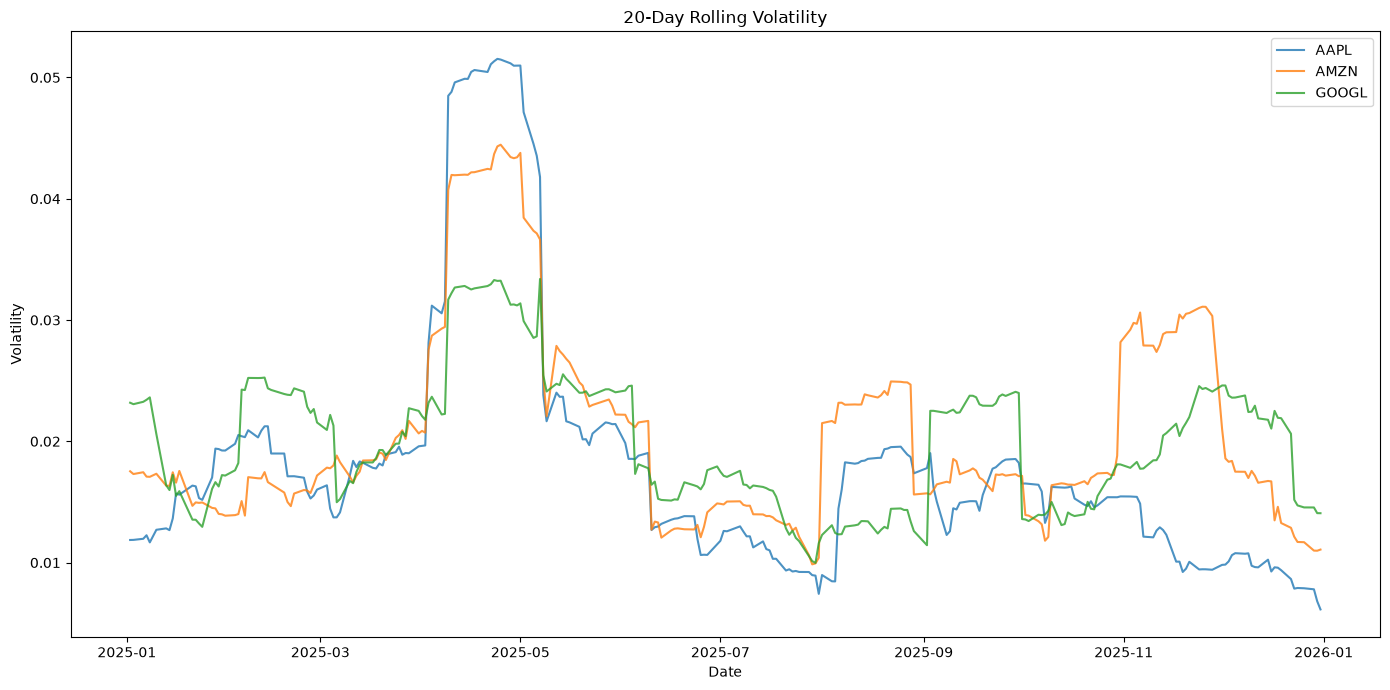

In [15]:
ticker_set = {"AAPL", "AMZN", "GOOGL"}
temp_data = data_processed[
    (data_processed['ticker'].isin(ticker_set)) &
    (data_processed['date'].dt.year == 2025)
]

plt.figure(figsize=(14, 7))

for ticker, group in temp_data.groupby("ticker"):
    plt.plot(
        group["date"],
        group["volatility_20d"],
        label=ticker,
        alpha=0.8
    )

plt.title("20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.tight_layout()
plt.show()

### 5d vs 20d Volatility Ratio

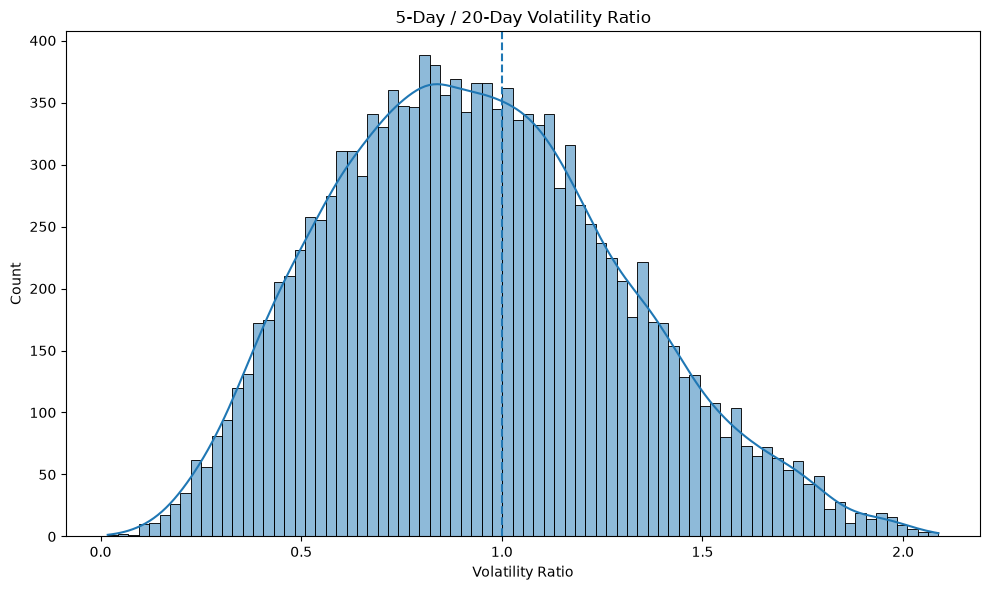

In [16]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data_processed["volatility_ratio_5d_20d"].dropna(), # type: ignore
    bins=80,
    kde=True
)

plt.axvline(1, linestyle="--")

plt.title("5-Day / 20-Day Volatility Ratio")
plt.xlabel("Volatility Ratio")
plt.tight_layout()
plt.show()

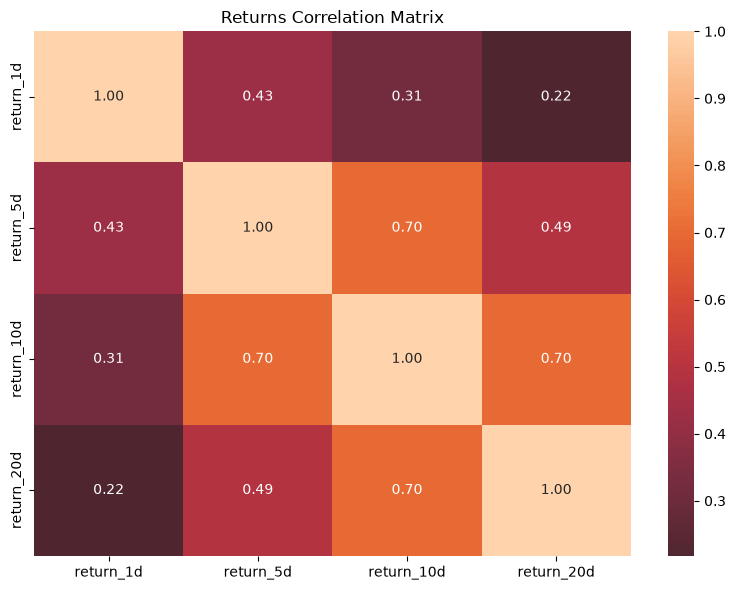

In [17]:
features = [
    "return_1d",
    "return_5d",
    "return_10d",
    "return_20d",
]

corr = data_processed[features].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    center=0
)

plt.title("Returns Correlation Matrix")
plt.tight_layout()
plt.show()

### Summary Statistics

In [18]:
year = 2025

data_year = data_processed[
    data_processed["date"].dt.year == year
]

ticker_summary = (
    data_year.groupby("ticker")
    .agg(
        mean_daily_return=("return_1d", "mean"),
        daily_return_std=("return_1d", "std"),
        mean_volatility_20d=("volatility_20d", "mean"),
        worst_drawdown_20d=("drawdown_20d", "min"),
    )
    .sort_values("mean_daily_return", ascending=False)
)

print(ticker_summary)

        mean_daily_return  daily_return_std  mean_volatility_20d  \
ticker                                                             
GOOGL            0.002219          0.020388             0.019870   
CAT              0.002030          0.020164             0.018572   
NVDA             0.001803          0.031256             0.028664   
JNJ              0.001511          0.012330             0.011619   
JPM              0.001309          0.015764             0.014332   
WMT              0.000962          0.015812             0.014708   
SPY              0.000680          0.012272             0.010226   
MSFT             0.000665          0.015291             0.014088   
XOM              0.000559          0.014810             0.014130   
AAPL             0.000535          0.020465             0.018062   
AMZN             0.000436          0.021684             0.020486   

        worst_drawdown_20d  
ticker                      
GOOGL            -0.190765  
CAT              -0.200502  

### Annualized return, Realized Return

In [19]:
# Annualized return based on mean daily return
ticker_summary["annualized_return"] = (
    (1 + ticker_summary["mean_daily_return"]) ** 252 - 1
)

ticker_summary["annualized_return_pct(%)"] = (
    ticker_summary["annualized_return"] * 100
)


# Actual realized return during 2025
realized_return = (
    data_year
    .groupby("ticker")["adjusted_close"]
    .agg(lambda x: x.iloc[-1] / x.iloc[0] - 1)
)

ticker_summary["realized_return"] = realized_return
ticker_summary["realized_return_pct(%)"] = realized_return * 100

ticker_summary.round(4)

,mean_daily_return,daily_return_std,mean_volatility_20d,worst_drawdown_20d,annualized_return,annualized_return_pct(%),realized_return,realized_return_pct(%)
ticker,,,,,,,,
GOOGL,0.0022,0.0204,0.0199,-0.1908,0.7484,74.8364,0.6588,65.8797
CAT,0.0020,0.0202,0.0186,-0.2005,0.6671,66.7069,0.6164,61.6369
NVDA,0.0018,0.0313,0.0287,-0.2365,0.5747,57.4700,0.3488,34.8789
JNJ,0.0015,0.0123,0.0116,-0.1034,0.4628,46.2816,0.4809,48.0939
JPM,0.0013,0.0158,0.0143,-0.1956,0.3903,39.0339,0.3710,37.1004
WMT,0.0010,0.0158,0.0147,-0.1956,0.2742,27.4219,0.2497,24.9738
SPY,0.0007,0.0123,0.0102,-0.1372,0.1869,18.6901,0.1801,18.0090
MSFT,0.0007,0.0153,0.0141,-0.1290,0.1824,18.2389,0.1639,16.3906
XOM,0.0006,0.0148,0.0141,-0.1605,0.1512,15.1215,0.1626,16.2582
